In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
dbset = sqlite3.connect("../DATA INGESTION/f1.db")


In [28]:
#LAPS

laps = pd.read_sql("""
    SELECT lap_duration, 
           duration_sector_1, duration_sector_2, duration_sector_3,
           i1_speed, i2_speed, st_speed
    FROM silver_laps
    WHERE lap_duration IS NOT NULL 
      AND lap_duration <= 200
""", dbset)

print(f"Rows loaded: {len(laps):,}")

print("Distribution summary:")
laps.describe()

Rows loaded: 194,097
Distribution summary:


,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,st_speed
count,194097.000000,193402.000000,193988.000000,193932.000000,175428.000000,193788.000000,184009.000000
mean,98.461950,31.072620,37.602093,29.596102,238.090111,236.090842,282.061910
std,21.568968,10.549031,9.900284,9.132200,54.996611,51.785982,49.358572
min,60.351000,16.251000,16.915000,15.941000,31.000000,26.000000,25.000000
25%,82.707000,25.212000,30.398000,23.733000,204.000000,196.000000,274.000000
50%,94.682000,29.594000,36.773000,27.197000,239.000000,245.000000,297.000000
75%,106.485000,33.669000,42.807000,33.554000,283.000000,275.000000,312.000000
max,199.997000,105.834000,99.678000,99.740000,359.000000,347.000000,364.000000


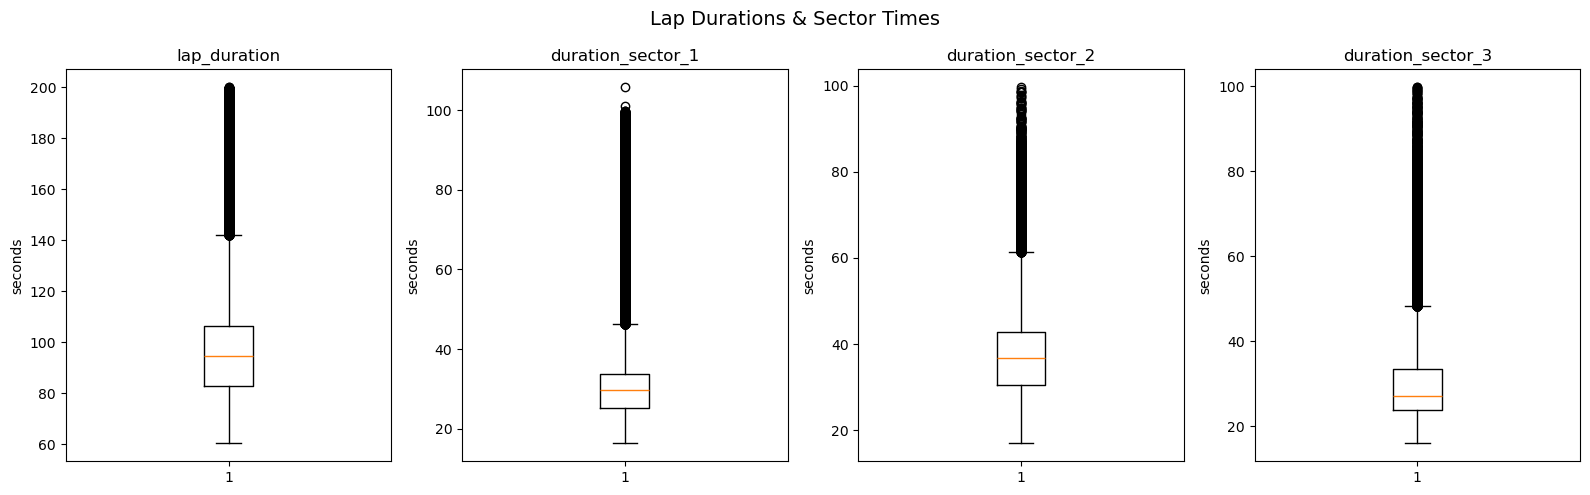

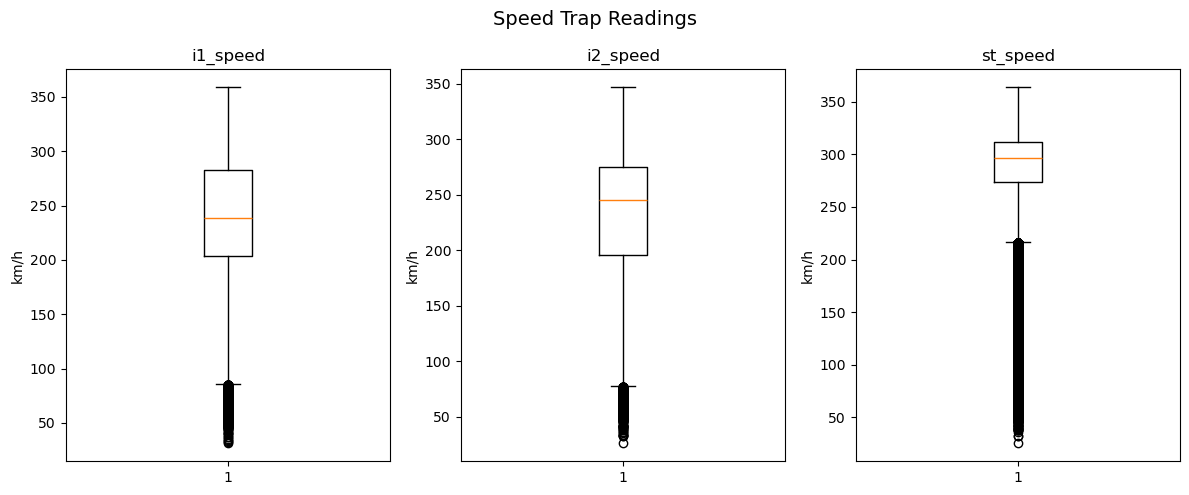

In [26]:
# Group 1: Durations (seconds)
duration_cols = ['lap_duration', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3']
fig, axes = plt.subplots(1, len(duration_cols), figsize=(16, 5))
for ax, col in zip(axes, duration_cols):
    ax.boxplot(laps[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('seconds')
plt.suptitle('Lap Durations & Sector Times', fontsize=14)
plt.tight_layout()
plt.show()

# Group 2: Speeds (km/h)
speed_cols = ['i1_speed', 'i2_speed', 'st_speed']
fig, axes = plt.subplots(1, len(speed_cols), figsize=(12, 5))
for ax, col in zip(axes, speed_cols):
    ax.boxplot(laps[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('km/h')
plt.suptitle('Speed Trap Readings', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
#INTERVALS 
intervals = pd.read_sql("""
    SELECT interval_seconds, gap_to_leader_seconds
    FROM silver_intervals
    WHERE interval_seconds BETWEEN 0 AND 40
       OR gap_to_leader_seconds BETWEEN 0 AND 100
""", dbset)


raw = pd.read_sql("""
    SELECT interval_seconds, gap_to_leader_seconds
    FROM silver_intervals
    WHERE interval_seconds IS NOT NULL OR gap_to_leader_seconds IS NOT NULL
""", dbset)

print("interval_seconds quantiles:")
print(raw['interval_seconds'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()


print("gap_to_leader_seconds quantiles:")
print(raw['gap_to_leader_seconds'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print(f"Rows loaded: {len(intervals):,}")

print("Distribution summary:")
intervals.describe()

interval_seconds quantiles:
0.50       2.04400
0.75       4.86400
0.90      10.64700
0.95      16.61600
0.99      37.67341
1.00    2443.42100
Name: interval_seconds, dtype: float64

gap_to_leader_seconds quantiles:
0.50      25.30800
0.75      46.85900
0.90      65.45630
0.95      74.64400
0.99      89.83533
1.00    2519.76100
Name: gap_to_leader_seconds, dtype: float64
Rows loaded: 1,862,283
Distribution summary:


,interval_seconds,gap_to_leader_seconds
count,1.838707e+06,1.693129e+06
mean,4.150062e+00,3.143007e+01
std,6.199458e+00,4.140223e+01
min,0.000000e+00,0.000000e+00
25%,9.070000e-01,1.190900e+01
50%,2.022000e+00,2.528700e+01
75%,4.763000e+00,4.681600e+01
max,2.948260e+02,2.519761e+03


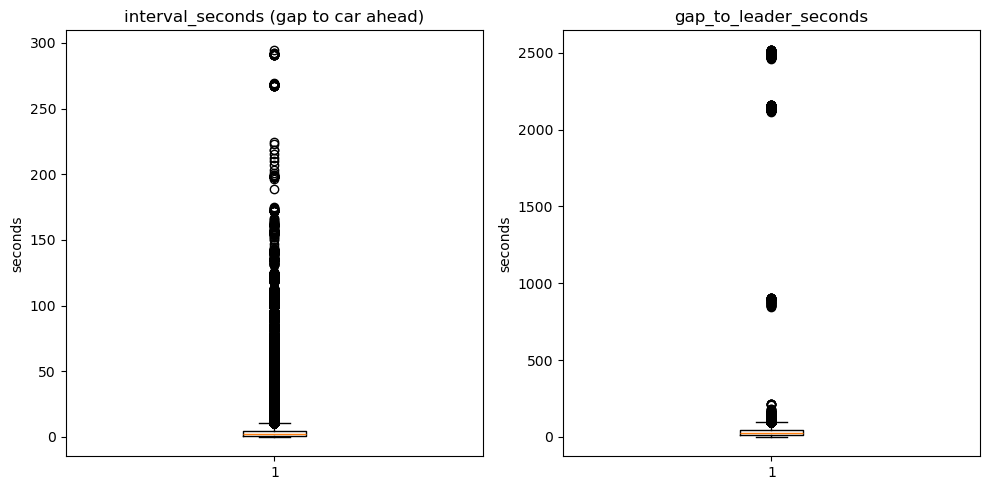

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(intervals['interval_seconds'].dropna())
axes[0].set_title('interval_seconds (gap to car ahead)')
axes[0].set_ylabel('seconds')

axes[1].boxplot(intervals['gap_to_leader_seconds'].dropna())
axes[1].set_title('gap_to_leader_seconds')
axes[1].set_ylabel('seconds')

plt.tight_layout()
plt.show()

In [63]:
#PIT 

raw = pd.read_sql("""
    SELECT stop_duration, lane_duration, pit_duration
    FROM silver_pit
""", dbset)

print("stop_duration quantiles:")
print(raw['stop_duration'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()
print("lane_duration quantiles:")
print(raw['lane_duration'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

pit = pd.read_sql("""
    SELECT stop_duration, lane_duration, pit_duration
    FROM silver_pit
    WHERE stop_duration BETWEEN 0 AND 20
       AND lane_duration BETWEEN 0 AND 2384
""", dbset)

print(f"Rows loaded: {len(pit):,}")
print("Distribution summary:")
pit.describe()

stop_duration quantiles:
0.50     2.70
0.75     3.40
0.90     5.30
0.95    10.00
0.99    17.96
1.00    38.30
Name: stop_duration, dtype: float64

lane_duration quantiles:
0.50      260.200
0.75      511.200
0.90      860.860
0.95     1262.980
0.99     2384.788
1.00    16921.800
Name: lane_duration, dtype: float64

Rows loaded: 953
Distribution summary:


,stop_duration,lane_duration,pit_duration
count,953.000000,953.000000,953.000000
mean,3.517524,24.124469,24.124469
std,2.485428,3.736748,3.736748
min,1.800000,17.042000,17.042000
25%,2.400000,22.038000,22.038000
50%,2.700000,23.342000,23.342000
75%,3.400000,24.900000,24.900000
max,19.800000,45.232000,45.232000


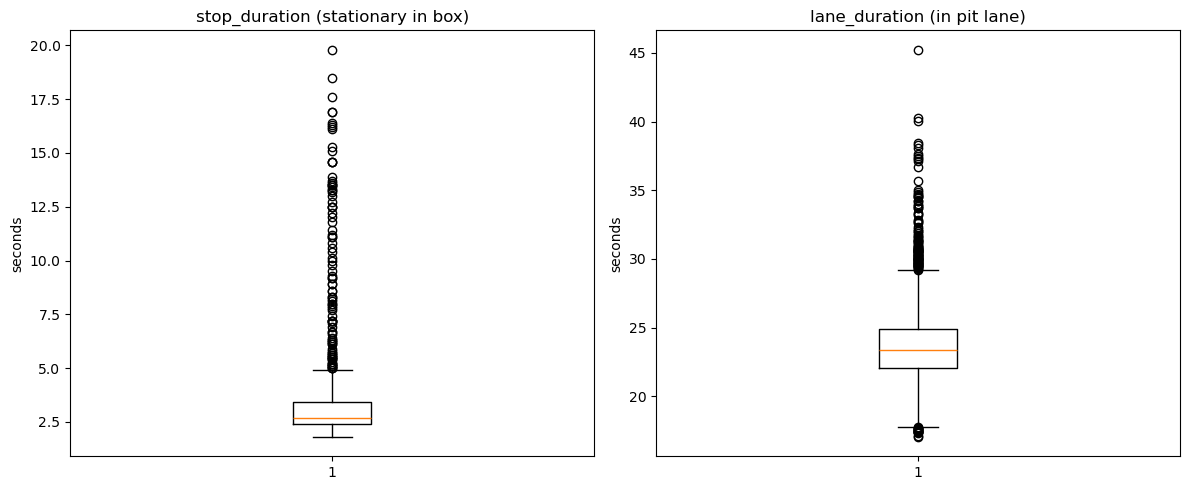

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(pit['stop_duration'].dropna())
axes[0].set_title('stop_duration (stationary in box)')
axes[0].set_ylabel('seconds')

axes[1].boxplot(pit['lane_duration'].dropna())
axes[1].set_title('lane_duration (in pit lane)')
axes[1].set_ylabel('seconds')


plt.tight_layout()
plt.show()



In [67]:
#SESSION RESULTS  

raw = pd.read_sql("""
    SELECT number_of_laps, duration_race_seconds , gap_to_leader_seconds
FROM silver_session_result
""", dbset)

print("number_of_laps quantiles:")
print(raw['number_of_laps'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()
print("duration_race_seconds quantiles:")
print(raw['duration_race_seconds'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()
print("gap_to_leader_seconds quantiles:")
print(raw['gap_to_leader_seconds'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()


session_result = pd.read_sql("""
    SELECT number_of_laps, duration_race_seconds , gap_to_leader_seconds
FROM silver_session_result
WHERE number_of_laps BETWEEN 1 AND 79
OR    duration_race_seconds BETWEEN 1 AND 6000
OR    gap_to_leader_seconds BETWEEN 0 AND 80
""", dbset)

print(f"Rows loaded: {len(session_result):,}")
print("Distribution summary:")
session_result.describe()

number_of_laps quantiles:
0.50     23.0
0.75     32.0
0.90     58.0
0.95     70.0
0.99     78.0
1.00    165.0
Name: number_of_laps, dtype: float64

duration_race_seconds quantiles:
0.50      90.6310
0.75     127.3580
0.90    5379.5056
0.95    5822.3288
0.99    7693.1670
1.00    9164.9650
Name: duration_race_seconds, dtype: float64

gap_to_leader_seconds quantiles:
0.50      1.2720
0.75      3.4070
0.90     42.5742
0.95     65.5282
0.99     88.0750
1.00    148.8410
Name: gap_to_leader_seconds, dtype: float64

Rows loaded: 7,572
Distribution summary:


,number_of_laps,duration_race_seconds,gap_to_leader_seconds
count,7572.000000,5158.000000,5157.000000
mean,28.917723,1226.429730,10.330559
std,19.467599,2199.859848,21.229004
min,1.000000,64.324000,0.000000
25%,17.000000,78.593250,0.666000
50%,23.000000,90.631000,1.272000
75%,32.000000,127.358000,3.407000
max,165.000000,9164.965000,148.841000


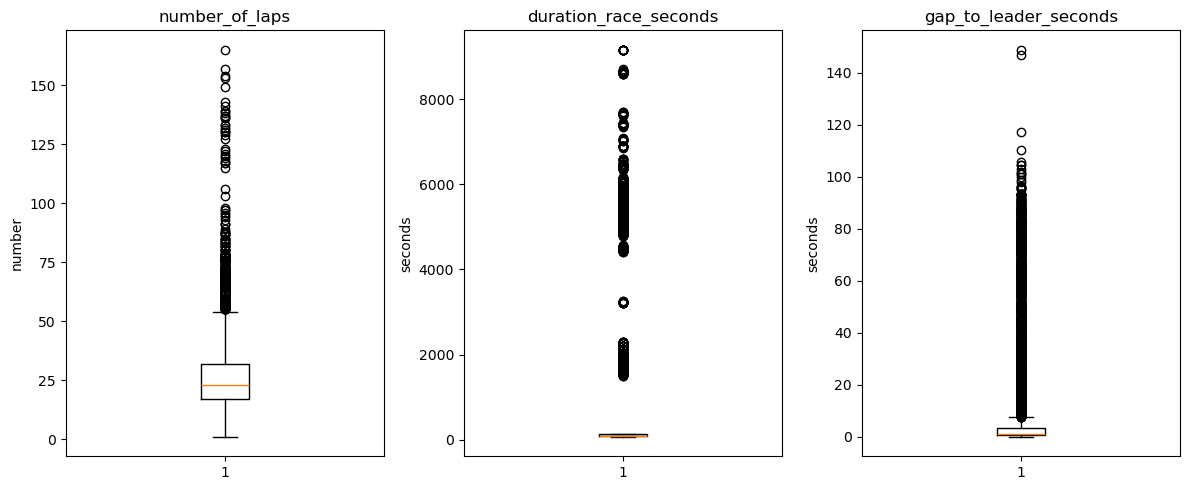

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].boxplot(session_result['number_of_laps'].dropna())
axes[0].set_title('number_of_laps')
axes[0].set_ylabel('number')

axes[1].boxplot(session_result['duration_race_seconds'].dropna())
axes[1].set_title('duration_race_seconds')
axes[1].set_ylabel('seconds')

axes[2].boxplot(session_result['gap_to_leader_seconds'].dropna())
axes[2].set_title('gap_to_leader_seconds')
axes[2].set_ylabel('seconds')

plt.tight_layout()
plt.show()

In [72]:
#STARTING GRID  

raw = pd.read_sql("""
    SELECT lap_duration
FROM silver_starting_grid
""", dbset)

print("lap_duration quantiles:")
print(raw['lap_duration'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

starting_grid = pd.read_sql("""
     SELECT lap_duration
FROM silver_starting_grid
WHERE lap_duration <= 120
""", dbset)

print(f"Rows loaded: {len(starting_grid):,}")
print("Distribution summary:")
starting_grid.describe()

lap_duration quantiles:
0.50     85.78400
0.75     92.33000
0.90    101.61520
0.95    107.33305
0.99    120.13402
1.00    128.51000
Name: lap_duration, dtype: float64

Rows loaded: 1,725
Distribution summary:


,lap_duration
count,1725.000000
mean,84.847164
std,11.411213
min,63.971000
25%,75.604000
50%,85.328000
75%,92.174000
max,119.915000


Text(0, 0.5, 'seconds')

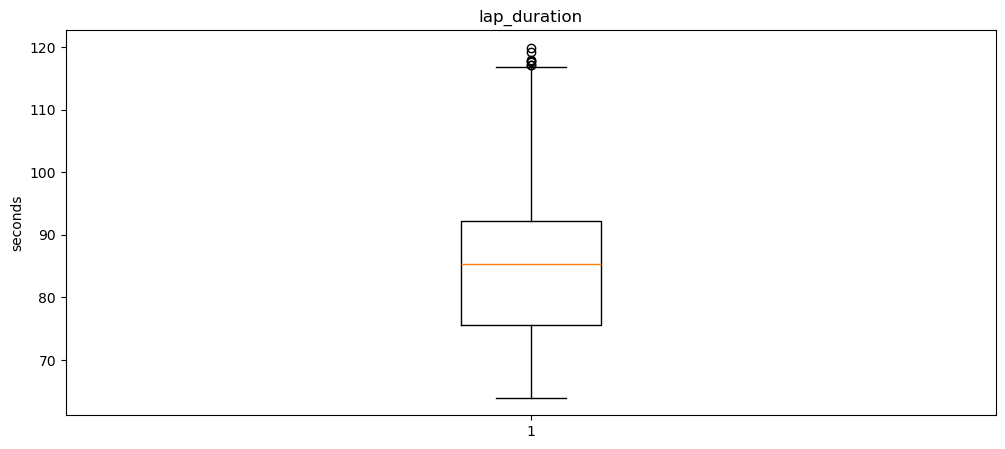

In [78]:
fig, axes = plt.subplots(1, figsize=(12, 5))

axes.boxplot(starting_grid['lap_duration'].dropna())

axes.set_title('lap_duration')
axes.set_ylabel('seconds')



In [80]:
#WEATHER

raw = pd.read_sql("""
    SELECT humidity , pressure , track_temperature , air_temperature , wind_speed , wind_direction
FROM silver_weather
""", dbset)

print("humidity quantiles:")
print(raw['humidity'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

print("pressure quantiles:")
print(raw['pressure'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

print("track_temperature quantiles:")
print(raw['track_temperature'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

print("air_temperature quantiles:")
print(raw['air_temperature'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

print("wind_speed quantiles:")
print(raw['wind_speed'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

print("wind_direction quantiles:")
print(raw['wind_direction'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))
print()

weather = pd.read_sql("""
     SELECT humidity , pressure , track_temperature , air_temperature , wind_speed , wind_direction
FROM silver_weather
""", dbset)

print(f"Rows loaded: {len(weather):,}")
print("Distribution summary:")
weather.describe()

humidity quantiles:
0.50    51.0
0.75    63.0
0.90    73.0
0.95    79.0
0.99    92.0
1.00    96.0
Name: humidity, dtype: float64

pressure quantiles:
0.50    1009.4
0.75    1016.3
0.90    1019.0
0.95    1020.5
0.99    1026.1
1.00    1031.0
Name: pressure, dtype: float64

track_temperature quantiles:
0.50    35.9
0.75    41.9
0.90    46.9
0.95    49.1
0.99    52.7
1.00    60.6
Name: track_temperature, dtype: float64

air_temperature quantiles:
0.50    24.4
0.75    27.9
0.90    30.1
0.95    31.3
0.99    34.1
1.00    35.8
Name: air_temperature, dtype: float64

wind_speed quantiles:
0.50    1.6
0.75    2.4
0.90    3.2
0.95    3.8
0.99    4.9
1.00    7.3
Name: wind_speed, dtype: float64

wind_direction quantiles:
0.50    180.0
0.75    259.0
0.90    322.0
0.95    340.0
0.99    355.0
1.00    360.0
Name: wind_direction, dtype: float64

Rows loaded: 42,915
Distribution summary:


,humidity,pressure,track_temperature,air_temperature,wind_speed,wind_direction
count,42915.000000,42915.000000,42915.000000,42915.000000,42915.000000,42915.000000
mean,50.455610,993.635638,35.118385,23.826627,1.784281,174.465338
std,17.707688,45.015022,9.155422,5.217713,1.050936,103.919454
min,9.000000,778.500000,-16.500000,10.700000,0.000000,0.000000
25%,37.000000,996.000000,29.200000,20.100000,1.000000,93.000000
50%,51.000000,1009.400000,35.900000,24.400000,1.600000,180.000000
75%,63.000000,1016.300000,41.900000,27.900000,2.400000,259.000000
max,96.000000,1031.000000,60.600000,35.800000,7.300000,360.000000


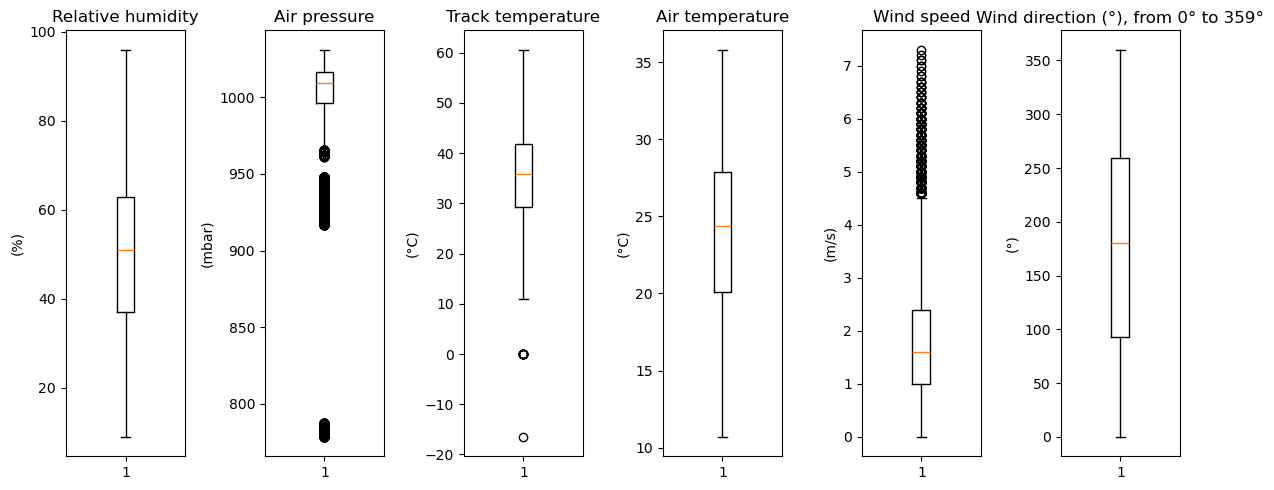

In [81]:
fig, axes = plt.subplots(1,6, figsize=(12, 5))
axes[0].boxplot(weather['humidity'].dropna())
axes[0].set_title('Relative humidity')
axes[0].set_ylabel('(%)')

axes[1].boxplot(weather['pressure'].dropna())
axes[1].set_title('Air pressure')
axes[1].set_ylabel('(mbar)')

axes[2].boxplot(weather['track_temperature'].dropna())
axes[2].set_title('Track temperature')
axes[2].set_ylabel('(°C)')

axes[3].boxplot(weather['air_temperature'].dropna())
axes[3].set_title('Air temperature')
axes[3].set_ylabel('(°C)')


axes[4].boxplot(weather['wind_speed'].dropna())
axes[4].set_title('Wind speed')
axes[4].set_ylabel('(m/s)')


axes[5].boxplot(weather['wind_direction'].dropna())
axes[5].set_title('Wind direction (°), from 0° to 359°')
axes[5].set_ylabel('(°)')

plt.tight_layout()
plt.show()